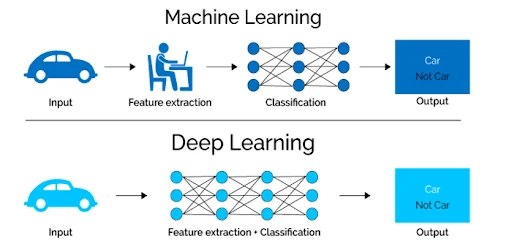

## 🔪 Let's try the first deep learning model with LSTM to address the limits from the baseline

### 🎒 Packages

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_colwidth', None)
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.svm import LinearSVC
import wandb
import numpy as np
import re

from collections import Counter
from torch.nn.utils.rnn import pad_sequence
import torch
from torch.nn import Module
from torch.utils.data import Dataset, DataLoader


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
print(device)

cuda


### 🚙 Utilities

In [4]:
train_path = Path("..") / ".." / "data" / "train" / "train.tsv"
# only used for final outputing (estimation on real data)
test_path = Path("..") / ".." / "data" / "test" / "train.tsv"

### 📊 Data

In [5]:
labels = ["Negative", "S. Negative", "Neural", "S. Positive", "Positive"]

In [6]:
df = pd.read_csv(train_path, sep="\t")
df.head()

,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,"A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .",1
1,2,1,A series of escapades demonstrating the adage that what is good for the goose,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


In [7]:
X, y = df["Phrase"], df["Sentiment"]

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

### 📖 Theories:
- A model that reads text word by word, and updates its understanding as it goes.
- “The movie was not good but still entertaining” -> read word -> update understanding -> read update understanding -> Final meaning: mixed but slightly positive
- word1 -> word2 -> word3 → ... -> wordN -> Keeping the memory, it has seen (`sequence` different from normal deep learning model, between there is no connection between inputs)
- It does NOT take: "this movie is good"
- It takes: [34, 87, 102, 5]
- Simple pipeline with LSTM:
  - [] Step 1: Text → tokens (words)
  - [] Step 2: Tokens → integers
  - [] Step 3: Fix length (padding)
  - [] Step 4: Final input shape
  - So now sentence becomes:

a sequence of vectors
- 1. Short-term memory (current step)
- 2. Long-term memory (cell state)
- 3. Gates (decision system)
🧠 6. Simple intuition in sentiment analysis

Sentence:

“not good but interesting”

LSTM learns:

Step	Memory update
not	store negation signal
good	flip sentiment negative
but	shift context
interesting	partially restore positive

👉 Final output:

mixed sentiment

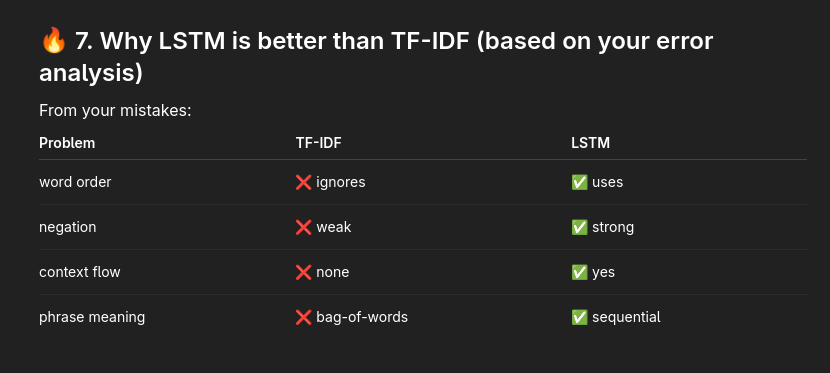

### 🧹 Preprocessing

In [9]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

In [10]:
X_train, X_val = X_train.apply(preprocess), X_val.apply(preprocess)

In [11]:
type(X_train)

pandas.Series

### 🌋 Build the vocabulary (Convert word into index)

In [12]:
def build_vocab(texts : pd.Series, max_size=20000):
    counter = Counter()
    
    for text in texts:
        words = text.split()
        counter.update(words)
    
    most_common = counter.most_common(max_size)
    
    vocab = {word: i+2 for i, (word, _) in enumerate(most_common)}
    
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    
    return vocab

In [13]:
vocab = build_vocab(X_train)

In [14]:
print(vocab)

{'the': 2, 'a': 3, 'of': 4, 'and': 5, 'to': 6, 's': 7, 'in': 8, 'is': 9, 'that': 10, 'it': 11, 'as': 12, 'with': 13, 'for': 14, 'its': 15, 'film': 16, 'an': 17, 'movie': 18, 'this': 19, 'but': 20, 'be': 21, 'you': 22, 'on': 23, 'nt': 24, 'by': 25, 'more': 26, 'his': 27, 'about': 28, 'one': 29, 'at': 30, 'not': 31, 'or': 32, 'from': 33, 'than': 34, 'all': 35, 'have': 36, 'like': 37, 'are': 38, 'has': 39, 'so': 40, 'story': 41, 'rrb': 42, 'out': 43, 'who': 44, 'most': 45, 'into': 46, 'too': 47, 'up': 48, 'lrb': 49, 'good': 50, 'if': 51, 'what': 52, 'their': 53, 'characters': 54, 'much': 55, 'can': 56, 'time': 57, 'i': 58, 'no': 59, 'your': 60, 'comedy': 61, 'some': 62, 'just': 63, 'does': 64, 'even': 65, 'little': 66, 'will': 67, 'funny': 68, 'way': 69, 'life': 70, 'any': 71, 'very': 72, 'only': 73, 'make': 74, 'been': 75, 'which': 76, 'he': 77, 'movies': 78, 'love': 79, 'do': 80, 'new': 81, 'there': 82, 'enough': 83, 'her': 84, 'work': 85, 'was': 86, 'bad': 87, 'they': 88, 'us': 89, 'ow

- Encode a sentence into a list of index
- "I will kill you"
- [32, 12, 34, 54]

In [15]:
def encode(text, vocab):
    return [vocab.get(word, vocab["<UNK>"]) for word in text.split()]

- Convert every sentence into a list of index
- List of list of index

In [16]:
X_train_seq = [encode(text, vocab) for text in X_train]
X_val_seq = [encode(text, vocab) for text in X_val]

- Padding sequence of numbers

In [17]:
MAX_LEN = 100

def pad(seq, max_len):
    # less than max_len -> padpad
    if len(seq) < max_len:
        seq = seq + [0]*(max_len - len(seq))
    else:
    # greater than max_len -> remove
        seq = seq[:max_len]
        
    # return the seq of index of MAX_LEN
    return seq

- for every seq (sen) in train -> pad, convert into a tensor [seq, seq, seq] [[12, 12, 12], [12, 12, 12]] -> 

In [18]:
X_train_pad = torch.tensor([pad(seq, MAX_LEN) for seq in X_train_seq])
X_val_pad = torch.tensor([pad(seq, MAX_LEN) for seq in X_val_seq])

y_train = torch.tensor(y_train.values)
y_val = torch.tensor(y_val.values)

In [19]:
X_train_pad.dim()

2

In [20]:
X_train_pad.shape

torch.Size([140454, 100])

- Now the data looks like: (batch_size, sequence_length)

### 🏐 Creating the dataset and dataloader for starting training

In [21]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [22]:
# dataset to manage the whole dataset 
train_dataset = TextDataset(X_train_pad, y_train)
val_dataset = TextDataset(X_val_pad, y_val)

# the loader to load batch from the dataset
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

### 🐡 Build the simple LSTM network

In [23]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        
        # ? What does that mean?
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        
        # ? What does that mean?
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        x = self.embedding(x)  
        # (batch, seq_len, embed_dim)
        
        _, (hidden, _) = self.lstm(x)
        # hidden: (1, batch, hidden_dim)
        
        out = hidden[-1]
        # (batch, hidden_dim)
        
        out = self.fc(out)
        return out

In [24]:
vocab_size = len(vocab)

model = LSTMModel(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=128,
    num_classes=5
)

In [25]:
model = model.to(device)

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [27]:
def train(model, loader):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

In [28]:
def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch)
            pred = outputs.argmax(dim=1)
            
            preds.extend(pred.tolist())
            labels.extend(y_batch.tolist())
    
    return preds, labels

In [29]:
#################################################################### - Set up configuration for this train
config = {
    "task": "sentiment_classification",
    "num_classes": 5,
    "model": "LSTM",
    "embedding_dim": 128,
    "hidden_dim": 128,
    "batch_size": 64,
    "epochs": 5,
    "learning_rate": 1e-3,
    "dataset": "Rotten Tomatoes"
}
#################################################################### - Init wandb
wandb.init(
    entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
    project="sentiment-analysis-on-movie-reviews",
    group="DL_LSTM",
    name="lstm_v1",
    config=config
)
#################################################################### - Traning step [Preprocessing - feature engineering]
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    
    for epoch in range(epochs):
        # ===== TRAIN =====
        model.train()
        total_loss = 0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_train_loss = total_loss / len(train_loader)
        
        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        preds, labels = [], []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                val_loss += loss.item()
                
                pred = outputs.argmax(dim=1)
                
                preds.extend(pred.cpu().numpy())   # move back to CPU
                labels.extend(y_batch.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_loader)
        
        # ===== METRICS =====
        acc = accuracy_score(labels, preds)
        f1_macro = f1_score(labels, preds, average="macro")
        f1_weighted = f1_score(labels, preds, average="weighted")
        
        # ===== LOG TO WANDB =====
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_accuracy": acc,
            "val_f1_macro": f1_macro,
            "val_f1_weighted": f1_weighted
        })
        
        print(f"""
        Epoch {epoch+1}
        Train Loss: {avg_train_loss:.4f}
        Val Loss: {avg_val_loss:.4f}
        Val Acc: {acc:.4f}
        Val F1 Macro: {f1_macro:.4f}
        """)
    
    # ===== FINAL CONFUSION MATRIX =====
    wandb.log({
        "confusion_matrix": wandb.plot.confusion_matrix(
            probs=None,
            y_true=labels,
            preds=preds,
            class_names=["0", "1", "2", "3", "4"]
        )
    })        
    
    
train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=wandb.config.epochs
)
#################################################################### - End

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/zun/.netrc.


wandb: Currently logged in as: trungdunglebui17112004 (trungdunglebui17112004-ho-chi-minh-city-university-of-te) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



        Epoch 1
        Train Loss: 1.2861
        Val Loss: 1.2844
        Val Acc: 0.5099
        Val F1 Macro: 0.1351
        

        Epoch 2
        Train Loss: 1.2850
        Val Loss: 1.2846
        Val Acc: 0.5099
        Val F1 Macro: 0.1351
        

        Epoch 3
        Train Loss: 1.2850
        Val Loss: 1.2872
        Val Acc: 0.5099
        Val F1 Macro: 0.1351
        

        Epoch 4
        Train Loss: 1.2851
        Val Loss: 1.2857
        Val Acc: 0.5099
        Val F1 Macro: 0.1351
        

        Epoch 5
        Train Loss: 1.2849
        Val Loss: 1.2841
        Val Acc: 0.5099
        Val F1 Macro: 0.1351
        


In [30]:
#################################################################### - Set up configuration for this train
config = {
    "task": "sentiment_classification",
    "num_classes": 5,
    "model": "LSTM",
    "embedding_dim": 128,
    "hidden_dim": 128,
    "batch_size": 64,
    "epochs": 50,
    "learning_rate": 1e-3,
    "dataset": "Rotten Tomatoes"
}
#################################################################### - Init wandb
wandb.init(
    entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
    project="sentiment-analysis-on-movie-reviews",
    group="DL_LSTM",
    name="lstm_v2",
    config=config
)
#################################################################### - Traning step [Preprocessing - feature engineering]
def train_model(model, train_loader, val_loader, optimizer, criterion, epochs):
    
    for epoch in range(epochs):
        # ===== TRAIN =====
        model.train()
        total_loss = 0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_train_loss = total_loss / len(train_loader)
        
        # ===== VALIDATION =====
        model.eval()
        val_loss = 0
        preds, labels = [], []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                val_loss += loss.item()
                
                pred = outputs.argmax(dim=1)
                
                preds.extend(pred.cpu().numpy())   # move back to CPU
                labels.extend(y_batch.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_loader)
        
        # ===== METRICS =====
        acc = accuracy_score(labels, preds)
        f1_macro = f1_score(labels, preds, average="macro")
        f1_weighted = f1_score(labels, preds, average="weighted")
        
        # ===== LOG TO WANDB =====
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_accuracy": acc,
            "val_f1_macro": f1_macro,
            "val_f1_weighted": f1_weighted
        })
        
        print(f"""
        Epoch {epoch+1}
        Train Loss: {avg_train_loss:.4f}
        Val Loss: {avg_val_loss:.4f}
        Val Acc: {acc:.4f}
        Val F1 Macro: {f1_macro:.4f}
        """)
    
    # ===== FINAL CONFUSION MATRIX =====
    wandb.log({
        "confusion_matrix": wandb.plot.confusion_matrix(
            probs=None,
            y_true=labels,
            preds=preds,
            class_names=["0", "1", "2", "3", "4"]
        )
    })        
    
    
train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs=wandb.config.epochs
)
#################################################################### - End

epoch,▁▃▅▆█
train_loss,█▂▁▂▁
val_accuracy,▁▁▁▁▁
val_f1_macro,▁▁▁▁▁
val_f1_weighted,▁▁▁▁▁
val_loss,▂▂█▅▁
epoch,5
train_loss,1.28491
val_accuracy,0.50993
val_f1_macro,0.13509
val_f1_weighted,0.34443



        Epoch 1
        Train Loss: 1.2849
        Val Loss: 1.2849
        Val Acc: 0.5099
        Val F1 Macro: 0.1351
        

        Epoch 2
        Train Loss: 1.2849
        Val Loss: 1.2840
        Val Acc: 0.5099
        Val F1 Macro: 0.1351
        

        Epoch 3
        Train Loss: 1.2850
        Val Loss: 1.2849
        Val Acc: 0.5099
        Val F1 Macro: 0.1351
        

        Epoch 4
        Train Loss: 1.2850
        Val Loss: 1.2844
        Val Acc: 0.5099
        Val F1 Macro: 0.1351
        

        Epoch 5
        Train Loss: 1.2849
        Val Loss: 1.2848
        Val Acc: 0.5099
        Val F1 Macro: 0.1351
        

        Epoch 6
        Train Loss: 1.2850
        Val Loss: 1.2860
        Val Acc: 0.5099
        Val F1 Macro: 0.1351
        

        Epoch 7
        Train Loss: 1.2849
        Val Loss: 1.2852
        Val Acc: 0.5099
        Val F1 Macro: 0.1351
        

        Epoch 8
        Train Loss: 1.2851
        Val Loss: 1.2840
        Val Ac